In [1]:
#%load_ext autoreload
%reload_ext autoreload
%autoreload 3

In [3]:
import sys
sys.path.append('../src')

try :
  from importlib import reload
  #reload(subsea.easy_search)
  #reload(subsea)
  reload(sub_es)
except NameError :
  #import subsea
  import subsea.easy_search as sub_es


In [4]:
df = sub_es.load( )

In [5]:
df.sample()

id,os,group,group_norm,group_physical,group_count,desc,date,class,class_norm,class_physical,class_count,un,un_norm,un_physical,un_count,field_number,field_location,field_location_norm,field_location_physical,field_location_count,depth,suit,suit_norm,suit_physical,suit_count,shipment,company,company_norm,company_physical,company_count,resource,resource_norm,resource_physical,resource_count,vessel,vessel_norm,vessel_physical,vessel_count,relatbar,n1710,files_count,files_size,files_missing_count,files_missing_size,files_oldest,files_newest,inventory_first,inventory_newest,files_missing_lastseen,bucket,bucket_norm,bucket_physical,bucket_count,base,folder,path,source
i32,str,cat,cat,u32,u32,str,date,cat,cat,u32,u32,cat,cat,u32,u32,i16,cat,cat,u32,u32,i32,cat,cat,u32,u32,str,cat,cat,u32,u32,cat,cat,u32,u32,cat,cat,u32,u32,str,str,i64,f64,i64,f64,date,date,date,date,date,cat,cat,u32,u32,str,str,str,str
73116,"""6000664129""","""CRD""","""crd""",195,4630,"""Intervencao em equipamentos in…",2022-12-21,"""Intervenção em equipamentos in…","""intervenção em equipamentos in…",152,3125,"""UN-ES - SEDE Espíri""","""un-es - sede espíri""",170,16085,65,"""7-BAZ-8-ESS""","""7-baz-8-ess""",1390,37,1448,"""Op. equip. / ATP-JUB UN-ES 202…","""op. equip. / atp-jub un-es 202…",4366,74,"""Manutencoes e operacoes probab…","""C-Innovation""","""c-innovation""",223,11916,"""RSV""","""rsv""",208,39667,"""Normand Poseidon""","""normand poseidon""",330,802,"""NPBAZ23-116""",null,25,1.6588e10,0,0.0,2023-09-11,2023-09-11,2023-09-17,2023-09-17,null,"""manutencao-inspecao-submarina""","""manutencao-inspecao-submarina""",217,51071,"""recursos-embarcacoes""","""OS006000664129-NPBAZ23-116""","""manutencao-inspecao-submarina/…","""Pacotes"""


In [6]:
df.shape

(74702, 58)

In [8]:
import polars as pl

In [11]:
df_sets = (
    df
      .select(["bucket", "os"])
      .group_by("bucket")
      .agg(pl.col("os").unique().alias("os_list"))
)

pairs = (
    df_sets.join(df_sets, how="cross", suffix="_2")
            .filter(pl.col("bucket") != pl.col("bucket_2"))
)

pairs = pairs.with_columns([
    pl.col("os_list").list.set_intersection("os_list_2").alias("intersection"),
    pl.col("os_list").list.set_union("os_list_2").alias("union"),
    (
        pl.col("os_list").list.set_intersection("os_list_2").list.len()
        /
        pl.col("os_list").list.set_union("os_list_2").list.len()
    ).alias("similarity")
])

In [13]:
pairs.sort("similarity", descending=True)

bucket,os_list,bucket_2,os_list_2,intersection,union,similarity
cat,list[str],cat,list[str],list[str],list[str],f64
"""interligacao-submarina""","[""6000783348"", ""6000739414"", … ""6000572855""]","""manutencao-inspecao-submarina""","[""6000789371"", ""6000749623"", … ""6000559301""]","[""6000722285"", ""6000778893"", … ""6000613530""]","[""6000783348"", ""6000739414"", … ""6000559301""]",0.020857
"""manutencao-inspecao-submarina""","[""6000789371"", ""6000749623"", … ""6000559301""]","""interligacao-submarina""","[""6000783348"", ""6000739414"", … ""6000572855""]","[""6000759678"", ""6000785215"", … ""6000572361""]","[""6000789371"", ""6000749623"", … ""6000572855""]",0.020857
"""interligacao-submarina""","[""6000783348"", ""6000739414"", … ""6000572855""]","""iesub-rsv""","[""6000780910"", ""6000780909"", … ""6000668109""]","[""6000722285"", ""6000776699"", … ""6000658519""]","[""6000783348"", ""6000739414"", … ""6000668109""]",0.01513
"""iesub-rsv""","[""6000780910"", ""6000780909"", … ""6000668109""]","""interligacao-submarina""","[""6000783348"", ""6000739414"", … ""6000572855""]","[""6000776699"", ""6000779038"", … ""6000668283""]","[""6000780910"", ""6000780909"", … ""6000572855""]",0.01513
"""servicos-arvore-de-natal-molha…","[""6000797937"", ""6000797560"", … ""6000604185""]","""iesub-rsv""","[""6000780910"", ""6000780909"", … ""6000668109""]","[""6000746423"", ""6000789697"", … ""6000670523""]","[""6000797937"", ""6000797560"", … ""6000668109""]",0.010776
…,…,…,…,…,…,…
"""instalacoes-equipamentos-subma…","[""6000740104"", ""6000752688"", … ""6000602544""]","""interligacao-submarina""","[""6000783348"", ""6000739414"", … ""6000572855""]","[""6000759829"", ""6000713603""]","[""6000740104"", ""6000752688"", … ""6000572855""]",0.000379
"""instalacoes-equipamentos-subma…","[""6000740104"", ""6000752688"", … ""6000602544""]","""manutencao-inspecao-submarina""","[""6000789371"", ""6000749623"", … ""6000559301""]","[""6000730018"", ""6000726922"", … ""6000612563""]","[""6000740104"", ""6000752688"", … ""6000559301""]",0.000293
"""manutencao-inspecao-submarina""","[""6000789371"", ""6000749623"", … ""6000559301""]","""instalacoes-equipamentos-subma…","[""6000740104"", ""6000752688"", … ""6000602544""]","[null, ""6000730018"", … ""6000612563""]","[""6000789371"", ""6000749623"", … ""6000602544""]",0.000293


In [14]:
pairs.filter(pl.col("similarity") > 0.80)

bucket,os_list,bucket_2,os_list_2,intersection,union,similarity
cat,list[str],cat,list[str],list[str],list[str],f64


In [17]:
import plotly.express as px
def bucket_similarity_matrix(df):
  df_sets = (
        df.select(["bucket", "os"]).unique()
          .group_by("bucket")
          .agg(pl.col("os").unique().alias("os_list"))
    )
  pairs = (
        df_sets.join(df_sets, how="cross", suffix="_2")
        .with_columns([
            pl.col("os_list").list.set_intersection("os_list_2").list.len().alias("inter_len"),
            pl.col("os_list").list.set_union("os_list_2").list.len().alias("union_len"),
        ])
        .with_columns((pl.col("inter_len") / pl.col("union_len")).alias("similarity"))
    )
  matrix = (
        pairs.select(["bucket", "bucket_2", "similarity"])
             .to_pandas()
             .pivot(index="bucket", columns="bucket_2", values="similarity")
             .fillna(0)
    )
  fig = px.imshow(
        matrix,
        text_auto=".2f",
        color_continuous_scale="Blues",
        aspect="auto"
    )
  fig.update_layout(
        title="Bucket Similarity Matrix",
        height=900, width=1100
    )
  fig.show()
  return matrix

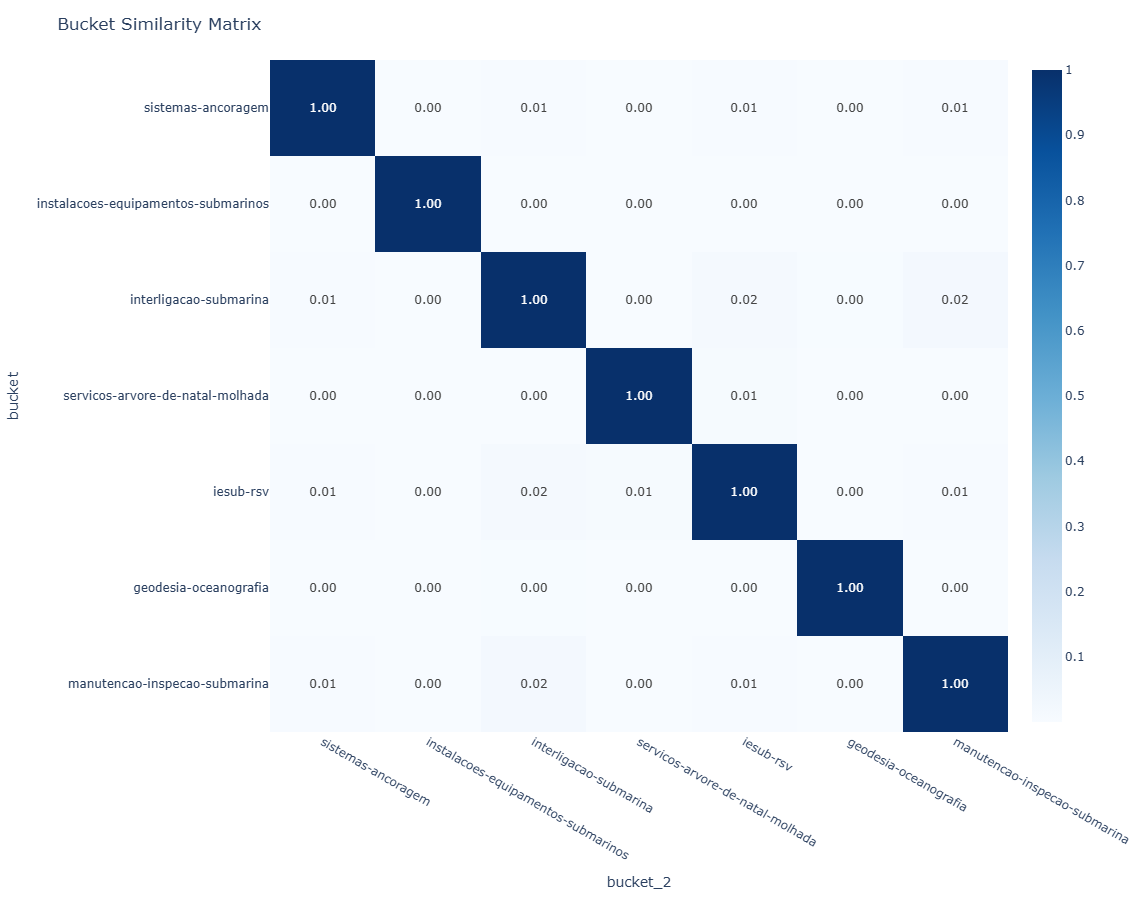

bucket_2,sistemas-ancoragem,instalacoes-equipamentos-submarinos,interligacao-submarina,servicos-arvore-de-natal-molhada,iesub-rsv,geodesia-oceanografia,manutencao-inspecao-submarina
bucket,,,,,,,
sistemas-ancoragem,1.000000,0.000161,0.007149,0.001507,0.005621,0.001815,0.005990
instalacoes-equipamentos-submarinos,0.000161,1.000000,0.000379,0.000772,0.001237,0.000998,0.000293
interligacao-submarina,0.007149,0.000379,1.000000,0.002508,0.015130,0.003831,0.020857
servicos-arvore-de-natal-molhada,0.001507,0.000772,0.002508,1.000000,0.010776,0.000972,0.001345
iesub-rsv,0.005621,0.001237,0.015130,0.010776,1.000000,0.001617,0.005456
geodesia-oceanografia,0.001815,0.000998,0.003831,0.000972,0.001617,1.000000,0.001920
manutencao-inspecao-submarina,0.005990,0.000293,0.020857,0.001345,0.005456,0.001920,1.000000


In [18]:
bucket_similarity_matrix(df)

bucket,os
cat,str
"""sistemas-ancoragem""","""6000792398"""
"""servicos-arvore-de-natal-molha…","""6000797937"""
"""servicos-arvore-de-natal-molha…","""6000797560"""
"""manutencao-inspecao-submarina""","""6000789371"""
"""manutencao-inspecao-submarina""","""6000749623"""
…,…
"""manutencao-inspecao-submarina""","""6000555846"""
"""manutencao-inspecao-submarina""","""6000542122"""
"""manutencao-inspecao-submarina""","""6000559301"""


In [ ]:
df.select( [ 'bucket', 'os' ] ).group_by( 'bucket' )